<a href="https://colab.research.google.com/github/swabhimansahu2004/Hybrid-TinyML-Environmental-Monitoring/blob/Swabhiman_Teacher_Model/Phase_6_Model_BenchMarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os

In [7]:
# 1. Load your original dataset
df = pd.read_csv('smoke_detection_iot.csv')

# 2. Features
features = ['Humidity[%]', 'Pressure[hPa]', 'Raw H2', 'NC2.5', 'NC1.0',
            'PM2.5', 'eCO2[ppm]', 'PM1.0', 'NC0.5', 'Temperature[C]',
            'TVOC[ppb]', 'Raw Ethanol']

X = df[features]
y = df['Fire Alarm']

# 3. Splits
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.125, random_state=42)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # <--- THIS WAS THE MISSING PIECE

print("✅ All data variables defined. You can now run the Benchmark cell.")

✅ All data variables defined. You can now run the Benchmark cell.


🚀 Benchmarking in progress... (This may take a minute)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


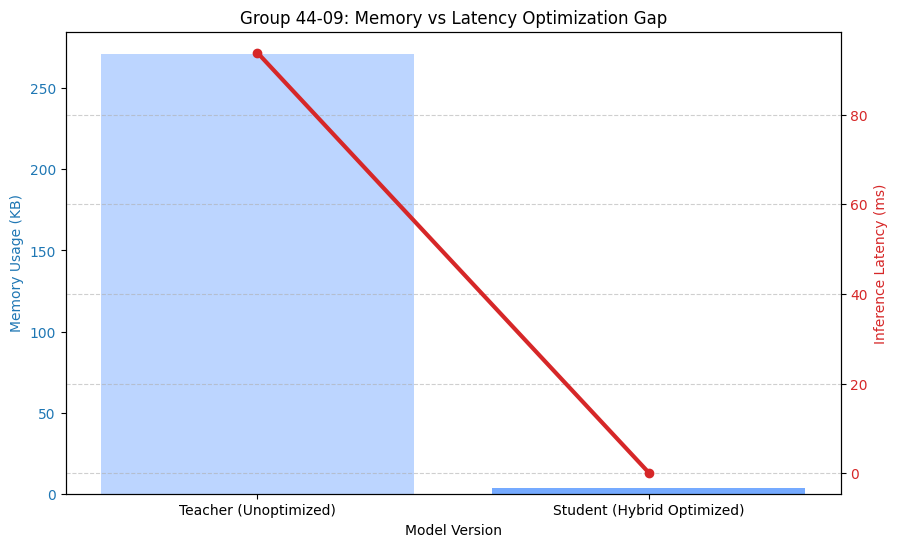


📈 RESEARCH FINDINGS:
Teacher Model: 271.27 KB | 93.8358 ms per inference
Optimized Student: 3.69 KB | 0.0889 ms per inference
🚀 Speedup Factor: 1055.1x faster


In [8]:
import time
import os

def benchmark_model(model_path, X_test_data, is_tflite=False):
    # 1. Measure Memory (File Size)
    size_kb = os.path.getsize(model_path) / 1024

    # 2. Measure Latency (Speed)
    start_time = time.time()
    iterations = 500 # Run 500 times to get a stable average

    if is_tflite:
        # Load TFLite interpreter
        interpreter = tf.lite.Interpreter(model_path=model_path)
        interpreter.allocate_tensors()
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        for i in range(iterations):
            sample = np.expand_dims(X_test_data[i], axis=0).astype(np.float32)
            interpreter.set_tensor(input_details[0]['index'], sample)
            interpreter.invoke()
            _ = interpreter.get_tensor(output_details[0]['index'])
    else:
        # Load Keras model
        model = tf.keras.models.load_model(model_path)
        for i in range(iterations):
            sample = np.expand_dims(X_test_data[i], axis=0)
            _ = model.predict(sample, verbose=0)

    end_time = time.time()
    avg_latency_ms = ((end_time - start_time) / iterations) * 1000

    return size_kb, avg_latency_ms

# --- RUN THE BENCHMARK ---
print("🚀 Benchmarking in progress... (This may take a minute)")
t_size, t_lat = benchmark_model('teacher_model.h5', X_test_scaled)
s_size, s_lat = benchmark_model('fire_model_optimized.tflite', X_test_scaled, is_tflite=True)

# --- VISUALIZE THE RESEARCH GAP ---
import matplotlib.pyplot as plt

labels = ['Teacher (Unoptimized)', 'Student (Hybrid Optimized)']
sizes = [t_size, s_size]
latencies = [t_lat, s_lat]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Memory Usage (Bar)
ax1.set_xlabel('Model Version')
ax1.set_ylabel('Memory Usage (KB)', color='tab:blue')
ax1.bar(labels, sizes, color=['#A0C4FF', '#3A86FF'], alpha=0.7, label='Memory (KB)')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Latency (Line)
ax2 = ax1.twinx()
ax2.set_ylabel('Inference Latency (ms)', color='tab:red')
ax2.plot(labels, latencies, color='tab:red', marker='o', linewidth=3, label='Latency (ms)')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Group 44-09: Memory vs Latency Optimization Gap')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"\n📈 RESEARCH FINDINGS:")
print(f"Teacher Model: {t_size:.2f} KB | {t_lat:.4f} ms per inference")
print(f"Optimized Student: {s_size:.2f} KB | {s_lat:.4f} ms per inference")
print(f"🚀 Speedup Factor: {t_lat/s_lat:.1f}x faster")